In [18]:
from importnb import imports
with imports("ipynb"):
    import functions  # type: ignore

In [19]:
# =============================================================================
#
# Pronostico usando un MLP
#
# =============================================================================
import warnings

warnings.filterwarnings("ignore")

#
# Carga de datos
#

df_orig = functions.load_data()
df_orig.head()

,yt_true
date,
1946-01-01,890
1946-02-01,992
1946-03-01,979
1946-04-01,959
1946-05-01,1110


In [20]:
#
# Construcción de la matriz de regresores
#
df_orig = functions.make_lagged_ts(
    df=df_orig,
    p_max=13,
    y_column="yt_true",
    fmt="lagged_{}m",
)
df_orig.head()

,yt_true,lagged_1m,lagged_2m,lagged_3m,lagged_4m,lagged_5m,lagged_6m,lagged_7m,lagged_8m,lagged_9m,lagged_10m,lagged_11m,lagged_12m,lagged_13m
date,,,,,,,,,,,,,,
1946-01-01,890,0,0,0,0,0,0,0,0,0,0,0,0,0
1946-02-01,992,890,0,0,0,0,0,0,0,0,0,0,0,0
1946-03-01,979,992,890,0,0,0,0,0,0,0,0,0,0,0
1946-04-01,959,979,992,890,0,0,0,0,0,0,0,0,0,0
1946-05-01,1110,959,979,992,890,0,0,0,0,0,0,0,0,0


In [21]:
#
# Remoción de los valores faltantes
#
df_dropna = df_orig.dropna()
df_dropna.head()

,yt_true,lagged_1m,lagged_2m,lagged_3m,lagged_4m,lagged_5m,lagged_6m,lagged_7m,lagged_8m,lagged_9m,lagged_10m,lagged_11m,lagged_12m,lagged_13m
date,,,,,,,,,,,,,,
1946-01-01,890,0,0,0,0,0,0,0,0,0,0,0,0,0
1946-02-01,992,890,0,0,0,0,0,0,0,0,0,0,0,0
1946-03-01,979,992,890,0,0,0,0,0,0,0,0,0,0,0
1946-04-01,959,979,992,890,0,0,0,0,0,0,0,0,0,0
1946-05-01,1110,959,979,992,890,0,0,0,0,0,0,0,0,0


In [22]:
#
# División de los datos en entrenamiento y prueba
#
(
    X_complete,
    y_complete,
    X_train,
    y_train,
    X_test,
    y_test,
) = functions.train_test_split(
    df=df_dropna,
    x_columns=[f"lagged_{i}m" for i in range(1, 13)],
    y_column="yt_true",
)
X_complete.head()

,lagged_1m,lagged_2m,lagged_3m,lagged_4m,lagged_5m,lagged_6m,lagged_7m,lagged_8m,lagged_9m,lagged_10m,lagged_11m,lagged_12m
date,,,,,,,,,,,,
1946-01-01,0,0,0,0,0,0,0,0,0,0,0,0
1946-02-01,890,0,0,0,0,0,0,0,0,0,0,0
1946-03-01,992,890,0,0,0,0,0,0,0,0,0,0
1946-04-01,979,992,890,0,0,0,0,0,0,0,0,0
1946-05-01,959,979,992,890,0,0,0,0,0,0,0,0


In [23]:
#
# Pronostico usando una red neuronal tipo MLP
#
from sklearn.compose import TransformedTargetRegressor  # type: ignore
from sklearn.neural_network import MLPRegressor  # type: ignore
from sklearn.pipeline import Pipeline  # type: ignore
from sklearn.preprocessing import MinMaxScaler  # type: ignore


# Crea un pipeline para automatizar la creacion de un modelo
def make_pipeline_from_model(model):
    """Create a pipeline."""
    return Pipeline(
        [
            (
                "scaler",
                MinMaxScaler(),
            ),
            (
                "regressor",
                TransformedTargetRegressor(
                    regressor=model,
                    transformer=MinMaxScaler(),
                ),
            ),
        ]
    )

In [24]:
#
# Entrenamiento y pronostico
#
hidden = 8
mlp_model = MLPRegressor(
    hidden_layer_sizes=(hidden,),
    activation="logistic",
    learning_rate="adaptive",
    momentum=0.01,
    learning_rate_init=0.2,
    max_iter=10000,
    random_state=123456,
)
mlp_pipeline = make_pipeline_from_model(model=mlp_model)
mlp_pipeline.fit(X_train, y_train)

df_dropna[f"yt_pred_mlp_{hidden}"] = mlp_pipeline.predict(X_complete)
df_dropna[["yt_true", f"yt_pred_mlp_{hidden}"]].head()

,yt_true,yt_pred_mlp_8
date,,
1946-01-01,890,1342.339438
1946-02-01,992,1478.018190
1946-03-01,979,1418.970172
1946-04-01,959,1365.377708
1946-05-01,1110,1260.042656


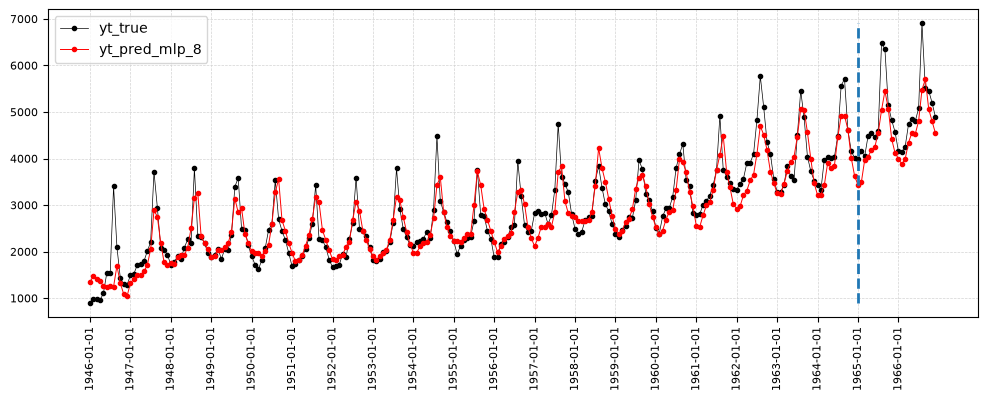

In [25]:
#
# Gráfica de los pronósticos
#
df_orig.loc[df_dropna.index, f"yt_pred_mlp_{hidden}"] = df_dropna[
    f"yt_pred_mlp_{hidden}"
]

functions.plot_time_series(df=df_orig, yt_col="yt_true")

In [26]:
#
# Almacenamiento de los resultados
#
functions.save_forecasts(df_orig)

In [27]:
#
# Métricas de error
#
metrics = functions.compute_evaluation_metrics(df_orig.dropna())
functions.save_metrics(metrics)
metrics

,Metrics,yt_pred_mlp_8
0,MSE Train,123422.63
1,MSE Test,310567.03
2,MAE Train,243.86
3,MAE Test,430.73
